# Chapter 4: Segment Arithmetic

Source orientation: Hartshorne, *Geometry: Euclid and Beyond*, Chapter 4, printed pp. 165-194 / PDF pp. 177-206, Sections 19-21. The PDF pages were used only to identify the route: segment operations, similar-triangle arithmetic, and coordinate recovery. The prose, code, diagrams, checks, and artifacts below are original.

## Chapter Question

Can arithmetic, ratios, and coordinates be recovered from geometric segment constructions alone?

## Chapter Goal

Explain how congruence classes of line segments become the positive part of an ordered field after a unit segment is chosen, how similar right triangles implement multiplication, and how those operations recover Cartesian coordinates for a Hilbert plane satisfying the parallel axiom.

## Computational Translation Guide

| Source-side idea | Computational representation | Check |
| --- | --- | --- |
| Congruence class of a segment | positive length variable, independent of position | translations keep size |
| Segment addition | laying representatives consecutively on a ray | endpoint sum is associative and commutative |
| Unit segment | calibration segment representing `1` | identity and unit-scaling checks |
| Segment multiplication | similar right triangles with a shared acute angle | equal slopes give product height |
| Similar triangles | proportional side triples in the field | ratio and Pythagorean identities |
| Coordinates | signed segment values on perpendicular axes | line equation and distance formula |
| Isomorphism | preservation of lines, betweenness, segment congruence, and angle congruence | dependency graph reaches every target |

## Route

1. Build a visual dependency route for the chapter.
2. Define addition by laying off segments.
3. Use a chosen unit to make a similar-triangle multiplication machine.
4. Inspect how changing the unit changes numeric labels and products.
5. Recover coordinates from axes, projections, line equations, and distance.
6. Run an applied lab and final sanity checks.


In [1]:
from pathlib import Path
import math, sys

start = Path.cwd().resolve()
candidates = [start, *start.parents]
for candidate in list(candidates):
    child = candidate / 'Euclid-and-Beyond'
    if child.exists():
        candidates.append(child)
BOOK_ROOT = None
for candidate in candidates:
    if (candidate / '00-book-index.ipynb').exists() and (candidate / 'utils').exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError('Could not find the Euclid and Beyond book root')
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

UNIT = 'chapter-04'
ARTIFACT_ROOT = BOOK_ROOT / 'artifacts'
UNIT_ROOT = ARTIFACT_ROOT / UNIT
for subdir in ['figures', 'interactive', 'tables', 'checks']:
    (UNIT_ROOT / subdir).mkdir(parents=True, exist_ok=True)

from IPython.display import display
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp

from utils.artifacts import artifact_path, assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.plotting import PALETTE

def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()

ARTIFACTS = []
CHECKS = {}
RESIDUALS = []

def record(path, role, min_bytes=512):
    ARTIFACTS.append({'path': rel(path), 'role': role, 'min_bytes': min_bytes})
    return path

def clean_axes(ax, equal=True):
    if equal:
        ax.set_aspect('equal')
    ax.axis('off')


## Standalone Reading Guide

Segment arithmetic is the chapter where synthetic geometry starts acting like algebra without abandoning construction. A segment is not first treated as a number; instead, a chosen unit segment lets addition, multiplication, and reciprocal operations be built by ruler-and-compass style configurations. Similar triangles are the mechanism that makes multiplication possible: parallel lines transfer ratios, and those ratios encode the product independently of the drawing scale.

The notebook's visuals should be read as machines. The addition diagram lays off representatives on a ray and checks that translation of the whole picture does not alter the resulting length. The multiplication machine shows how a unit choice, an input segment, and a second segment determine a fourth segment by similarity. The coordinate-recovery section explains why this matters: once segment arithmetic is available, geometric points can be assigned coordinates and geometric statements can be tested by algebraic identities. The dependency graph keeps track of which geometric facts are doing the work rather than treating coordinates as magic.

The applied lab varies the unit and the two input segments on purpose. If the construction is genuinely geometric, changing the unit rescales the coordinate description in a predictable way while preserving the intended ratio statement. The final checks therefore focus on exact symbolic identities and near-zero residuals from the generated constructions, not on the appearance of a single diagram.


A useful way to audit this chapter is to ask which facts would survive if the picture were redrawn larger, rotated, or translated. Pure length labels can change with the chosen unit, but ratios produced by the similar-triangle construction should remain consistent. That is why the notebook records both diagrams and tables: the diagram shows the construction dependency, while the table checks that the same arithmetic relation survives across several numeric choices.


The final conceptual payoff is that arithmetic is no longer external bookkeeping. Once a segment construction realizes addition and multiplication, a geometric theorem can be moved into coordinate form and then moved back into construction form. That two-way passage is the bridge to the field-based chapters.
 The lab also flags scale mistakes immediately. A zero residual is the certificate. This closes the loop.

## A Route Map For Segment Arithmetic

The chapter starts with segment congruence classes rather than numbers. Addition can be read from endpoints on one ray. Multiplication needs one extra datum: a unit segment that makes a right-triangle slope into a product. Once those operations form a field, similar triangles and coordinates can be rebuilt in field language.

Inspect where `Choose unit` enters the route: it feeds multiplication, not addition.

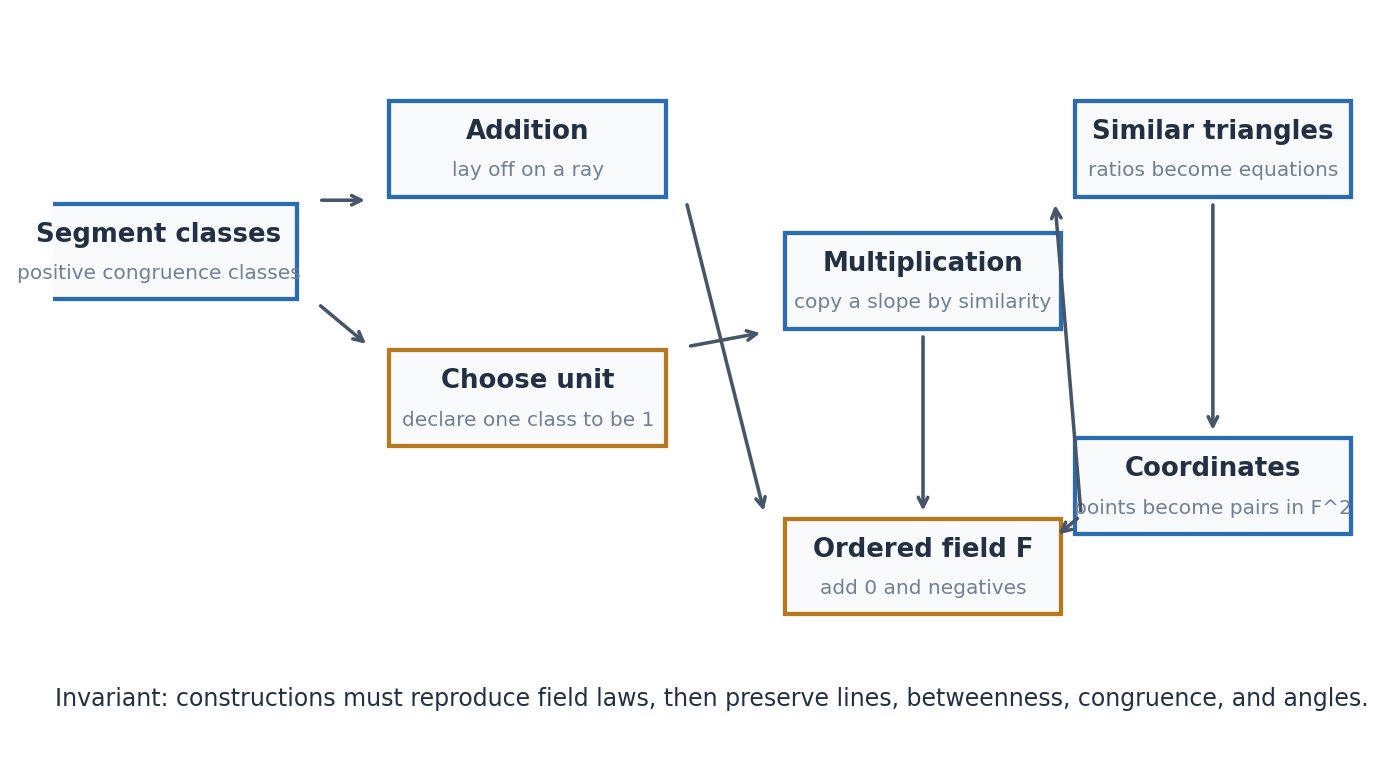

{'artifact': 'artifacts/chapter-04/figures/segment-arithmetic-machine.png',
 'node_count': 7,
 'edge_count': 8,
 'is_acyclic': True,
 'unit_feeds_product': True}

In [2]:
fig, ax = plt.subplots(figsize=(10, 5.6)); clean_axes(ax, equal=False)
nodes = {
    'segments': (0.08, 0.68, 'Segment classes', 'positive congruence classes'),
    'addition': (0.36, 0.82, 'Addition', 'lay off on a ray'),
    'unit': (0.36, 0.48, 'Choose unit', 'declare one class to be 1'),
    'product': (0.66, 0.64, 'Multiplication', 'copy a slope by similarity'),
    'field': (0.66, 0.25, 'Ordered field F', 'add 0 and negatives'),
    'similarity': (0.88, 0.82, 'Similar triangles', 'ratios become equations'),
    'coordinates': (0.88, 0.36, 'Coordinates', 'points become pairs in F^2'),
}
edges = [('segments','addition'),('segments','unit'),('addition','field'),('unit','product'),('product','field'),('field','similarity'),('field','coordinates'),('similarity','coordinates')]
for key, (x, y, title, detail) in nodes.items():
    color = PALETTE['gold'] if key in {'unit','field'} else PALETTE['blue']
    ax.add_patch(plt.Rectangle((x-.105,y-.065),.21,.13,fc='#f8fafc',ec=color,lw=1.8))
    ax.text(x,y+.023,title,ha='center',va='center',fontsize=11,weight='bold',color=PALETTE['ink'])
    ax.text(x,y-.030,detail,ha='center',va='center',fontsize=8.5,color=PALETTE['gray'])
for s,t in edges:
    x0,y0,*_ = nodes[s]; x1,y1,*_ = nodes[t]
    ax.annotate('', xy=(x1-.12*np.sign(x1-x0),y1-.07*np.sign(y1-y0)), xytext=(x0+.12*np.sign(x1-x0),y0+.07*np.sign(y1-y0)), arrowprops={'arrowstyle':'->','lw':1.5,'color':'#475569'})
ax.text(.5,.06,'Invariant: constructions must reproduce field laws, then preserve lines, betweenness, congruence, and angles.',ha='center',fontsize=10,color=PALETTE['ink'])
route_path = save_matplotlib(fig, UNIT, 'figures', 'segment-arithmetic-machine.png', root=ARTIFACT_ROOT, dpi=170); plt.close(fig)
G = nx.DiGraph(edges)
CHECKS['route'] = {'artifact': rel(route_path), 'node_count': len(nodes), 'edge_count': len(edges), 'is_acyclic': nx.is_directed_acyclic_graph(G), 'unit_feeds_product': nx.has_path(G,'unit','product')}
assert CHECKS['route']['is_acyclic'] and CHECKS['route']['unit_feeds_product']
record(route_path, 'chapter dependency route', 1200)
display_artifact(route_path, width=920)
CHECKS['route']


## 1. Segment Addition: Lay Off Representatives

A segment class records size but not position. To add two classes, place a representative for `b` immediately after a representative for `a` on the same ray and read the whole segment. The visual compares `a+b+c`, `(a+b)+c`, and `a+(b+c)`. The invariant is the endpoint.

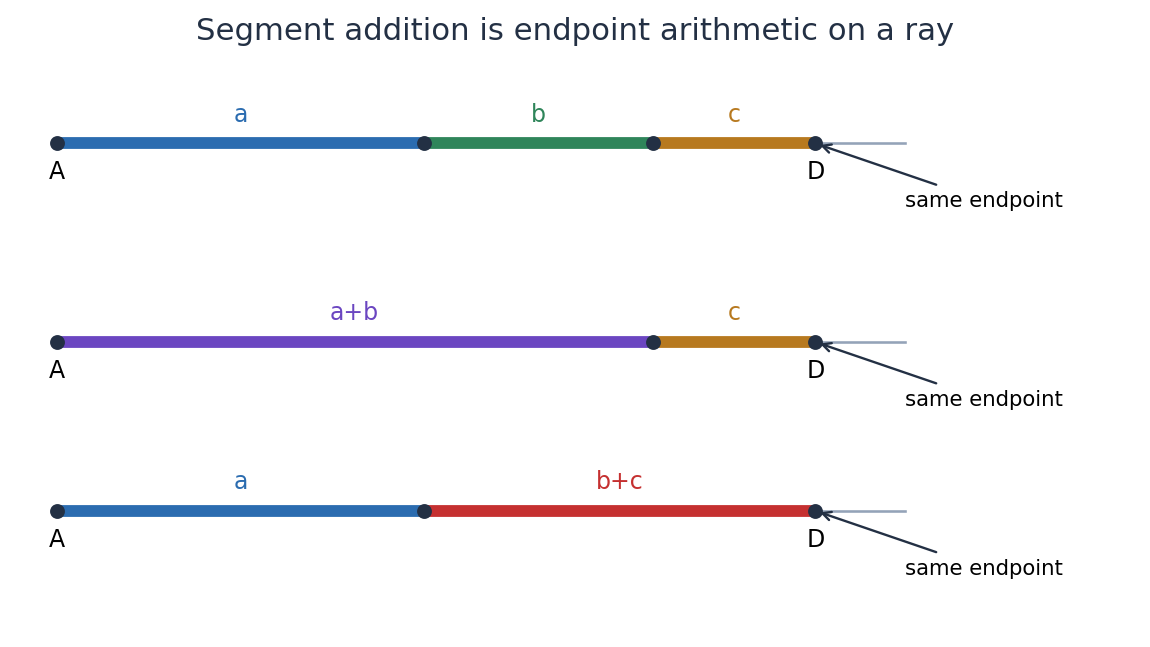

{'a': 1.85,
 'b': 1.15,
 'c': 0.82,
 'direct_sum': 3.82,
 'left_group_sum': 3.82,
 'right_group_sum': 3.82,
 'commutative_residual': 0.0,
 'associative_residual': 0.0}

In [3]:
a_len, b_len, c_len = 1.85, 1.15, 0.82
fig, ax = plt.subplots(figsize=(10, 4.4)); clean_axes(ax)

def draw_ray(y, lengths, labels, colors):
    x = 0.0
    ax.plot([0, sum(lengths)+.45], [y, y], color='#94a3b8', lw=1.1)
    ax.scatter([0], [y], color=PALETTE['ink'], s=28, zorder=4); ax.text(0, y-.18, 'A', ha='center')
    for length, label, color in zip(lengths, labels, colors):
        x2 = x + length
        ax.plot([x, x2], [y, y], color=color, lw=5, solid_capstyle='butt')
        ax.scatter([x2], [y], color=PALETTE['ink'], s=28, zorder=4)
        ax.text((x+x2)/2, y+.11, label, ha='center', fontsize=10, color=color)
        x = x2
    ax.text(x, y-.18, 'D', ha='center')
    return x

t0 = draw_ray(2.1, [a_len,b_len,c_len], ['a','b','c'], [PALETTE['blue'],PALETTE['green'],PALETTE['gold']])
t1 = draw_ray(1.1, [a_len+b_len,c_len], ['a+b','c'], [PALETTE['purple'],PALETTE['gold']])
t2 = draw_ray(.25, [a_len,b_len+c_len], ['a','b+c'], [PALETTE['blue'],PALETTE['red']])
for y,t in [(2.1,t0),(1.1,t1),(.25,t2)]:
    ax.annotate('same endpoint', xy=(t,y), xytext=(t+.45,y-.32), arrowprops={'arrowstyle':'->','color':PALETTE['ink']}, fontsize=9)
ax.set_xlim(-.2, t0+1.6); ax.set_ylim(-.35,2.55)
ax.set_title('Segment addition is endpoint arithmetic on a ray', fontsize=13, color=PALETTE['ink'])
addition_path = save_matplotlib(fig, UNIT, 'figures', 'segment-addition-order.png', root=ARTIFACT_ROOT, dpi=170); plt.close(fig)
checks = {'a':a_len,'b':b_len,'c':c_len,'direct_sum':a_len+b_len+c_len,'left_group_sum':(a_len+b_len)+c_len,'right_group_sum':a_len+(b_len+c_len),'commutative_residual':abs((a_len+b_len)-(b_len+a_len)),'associative_residual':abs(((a_len+b_len)+c_len)-(a_len+(b_len+c_len)))}
CHECKS['addition'] = checks; RESIDUALS += [checks['commutative_residual'], checks['associative_residual']]
assert checks['commutative_residual'] < 1e-12 and checks['associative_residual'] < 1e-12
record(addition_path, 'segment addition construction', 1200)
display_artifact(addition_path, width=920)
checks


## 2. Multiplication: A Similar-Triangle Machine

Multiplication needs a calibration segment. First choose a unit segment. Build a right triangle with base `1` and height `a`; its acute angle stores the slope `a/1`. Build a second right triangle with the same angle and base `b`. Its height is forced to be `ab`, because the slopes agree.

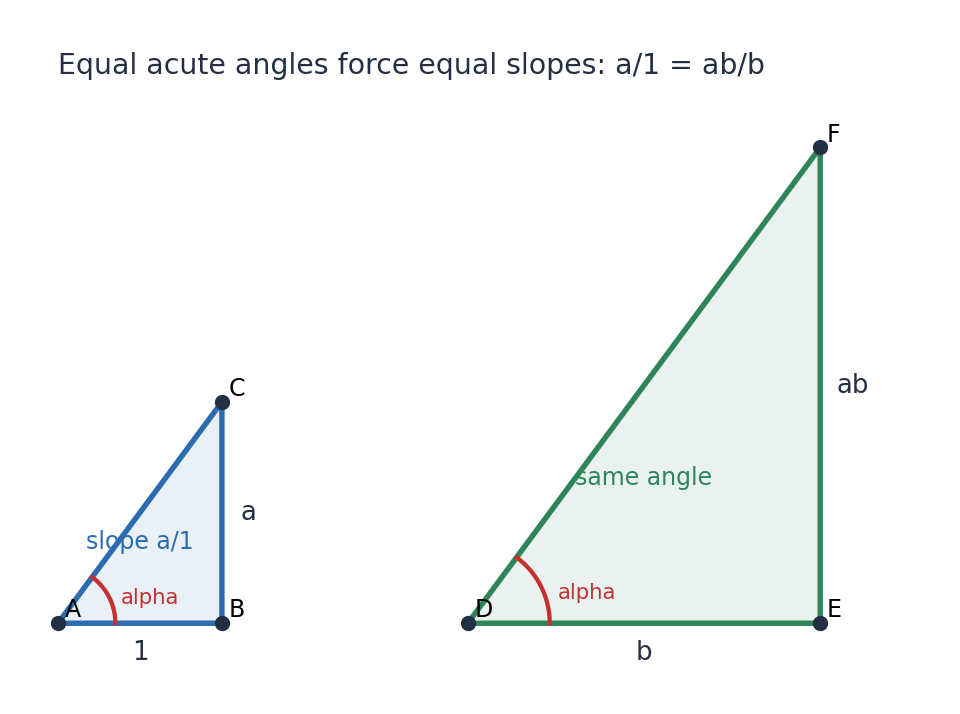

{'unit_length': 1.0,
 'a': 1.35,
 'b': 2.15,
 'constructed_product': 2.9025,
 'expected_product': 2.9025,
 'slope_residual': 0.0,
 'symbolic_slope_identity': '0',
 'symbolic_unit_identity': '0',
 'symbolic_distributive_identity_with_unit': '0'}

In [4]:
unit_len, seg_a, seg_b = 1.0, 1.35, 2.15
prod = seg_a * seg_b / unit_len
fig, ax = plt.subplots(figsize=(10,5.2)); clean_axes(ax)
A=np.array([0.,0.]); B=np.array([unit_len,0.]); C=np.array([unit_len,seg_a])
D=np.array([2.5,0.]); E=np.array([2.5+seg_b,0.]); F=np.array([2.5+seg_b,prod])
for pts,color,label in [([A,B,C,A],PALETTE['blue'],'slope a/1'),([D,E,F,D],PALETTE['green'],'same angle')]:
    arr=np.vstack(pts); ax.plot(arr[:,0],arr[:,1],color=color,lw=2.3); ax.fill(arr[:,0],arr[:,1],color=color,alpha=.10); ax.text(arr[:,0].mean(),arr[:,1].mean()+.12,label,ha='center',fontsize=10,color=color)
for label,p,off in [('A',A,(.04,.04)),('B',B,(.04,.04)),('C',C,(.04,.04)),('D',D,(.04,.04)),('E',E,(.04,.04)),('F',F,(.04,.04))]:
    ax.scatter([p[0]],[p[1]],color=PALETTE['ink'],s=30,zorder=4); ax.text(p[0]+off[0],p[1]+off[1],label,fontsize=10)
for label,p in [('1',(A+B)/2+[0,-.18]),('a',(B+C)/2+[.16,0]),('b',(D+E)/2+[0,-.18]),('ab',(E+F)/2+[.2,0])]:
    ax.text(p[0],p[1],label,ha='center',va='center',fontsize=11,color=PALETTE['ink'])
arc=np.linspace(0,math.atan(seg_a/unit_len),35)
ax.plot(.35*np.cos(arc),.35*np.sin(arc),color=PALETTE['red'],lw=1.8); ax.plot(D[0]+.5*np.cos(arc),D[1]+.5*np.sin(arc),color=PALETTE['red'],lw=1.8)
ax.text(.38,.12,'alpha',color=PALETTE['red'],fontsize=9); ax.text(D[0]+.55,D[1]+.15,'alpha',color=PALETTE['red'],fontsize=9)
ax.text(0,prod+.45,'Equal acute angles force equal slopes: a/1 = ab/b',fontsize=12,color=PALETTE['ink'])
ax.set_xlim(-.25,E[0]+.75); ax.set_ylim(-.45,prod+.8)
product_path = save_matplotlib(fig, UNIT, 'figures', 'similar-triangle-product-machine.png', root=ARTIFACT_ROOT, dpi=170); plt.close(fig)
u,a,b=sp.symbols('u a b', positive=True)
slope_id=sp.simplify(a/u-(a*b/u)/b); unit_id=sp.simplify(a*u/u-a); dist_id=sp.expand(a*(b+u)/u-(a*b/u+a))
checks={'unit_length':unit_len,'a':seg_a,'b':seg_b,'constructed_product':prod,'expected_product':seg_a*seg_b,'slope_residual':abs(seg_a/unit_len-prod/seg_b),'symbolic_slope_identity':str(slope_id),'symbolic_unit_identity':str(unit_id),'symbolic_distributive_identity_with_unit':str(dist_id)}
CHECKS['multiplication']=checks; RESIDUALS.append(checks['slope_residual'])
assert slope_id == 0 and unit_id == 0 and dist_id == 0 and checks['slope_residual'] < 1e-12
record(product_path, 'similar-triangle multiplication construction', 1200)
display_artifact(product_path, width=920)
checks


## 3. Choosing The Unit Segment

The unit is not decorative. Addition of two physical segments does not depend on a unit, but multiplication does: the product segment has physical length `a_length*b_length/unit_length`. Choosing `1` fixes the multiplicative identity and the scale of every numeric label.

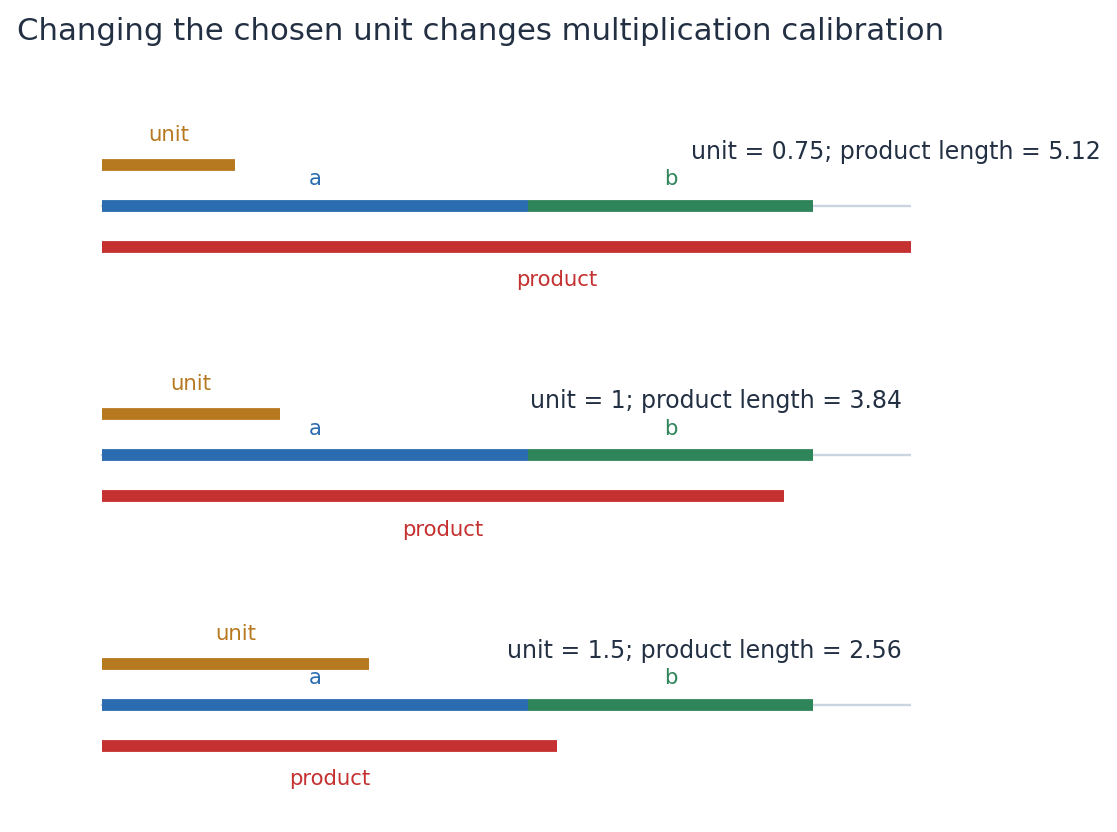

,unit_length,a_label,b_label,sum_length,product_length,product_label,label_product,identity_check_length
0,0.75,3.2,2.133333,4.0,5.12,6.826667,6.826667,2.4
1,1.00,2.4,1.600000,4.0,3.84,3.840000,3.840000,2.4
2,1.50,1.6,1.066667,4.0,2.56,1.706667,1.706667,2.4


In [5]:
phys_a, phys_b = 2.4, 1.6
units = np.array([0.75, 1.0, 1.5])
rows=[]
for u0 in units:
    a_label, b_label = phys_a/u0, phys_b/u0
    product_length = phys_a*phys_b/u0
    rows.append({'unit_length':u0,'a_label':a_label,'b_label':b_label,'sum_length':phys_a+phys_b,'product_length':product_length,'product_label':product_length/u0,'label_product':a_label*b_label,'identity_check_length':phys_a*u0/u0})
unit_table=pd.DataFrame(rows)
fig,axes=plt.subplots(len(units),1,figsize=(10,5.4),sharex=True)
for ax,row in zip(axes,rows):
    clean_axes(ax); u0=row['unit_length']; max_x=max(row['product_length'], phys_a+phys_b)+.55
    ax.plot([0,max_x],[0,0],color='#cbd5e1',lw=1)
    ax.plot([0,u0],[.23,.23],color=PALETTE['gold'],lw=5,solid_capstyle='butt'); ax.text(u0/2,.37,'unit',ha='center',fontsize=9,color=PALETTE['gold'])
    ax.plot([0,phys_a],[0,0],color=PALETTE['blue'],lw=5,solid_capstyle='butt'); ax.plot([phys_a,phys_a+phys_b],[0,0],color=PALETTE['green'],lw=5,solid_capstyle='butt')
    ax.plot([0,row['product_length']],[-.23,-.23],color=PALETTE['red'],lw=5,solid_capstyle='butt')
    ax.text(phys_a/2,.12,'a',ha='center',fontsize=9,color=PALETTE['blue']); ax.text(phys_a+phys_b/2,.12,'b',ha='center',fontsize=9,color=PALETTE['green'])
    ax.text(row['product_length']/2,-.45,'product',ha='center',fontsize=9,color=PALETTE['red'])
    ax.text(max_x-.05,.27,f"unit = {u0:g}; product length = {row['product_length']:.2f}",ha='right',fontsize=10,color=PALETTE['ink'])
    ax.set_xlim(-.05,max_x); ax.set_ylim(-.62,.55)
fig.suptitle('Changing the chosen unit changes multiplication calibration', fontsize=13, color=PALETTE['ink'])
unit_path=save_matplotlib(fig, UNIT, 'figures', 'unit-segment-scale-choice.png', root=ARTIFACT_ROOT, dpi=170); plt.close(fig)
checks={'same_physical_inputs':{'a':phys_a,'b':phys_b},'addition_length_all_units':unit_table['sum_length'].round(12).unique().tolist(),'max_label_product_residual':float(np.max(np.abs(unit_table['product_label']-unit_table['label_product']))),'max_identity_residual':float(np.max(np.abs(unit_table['identity_check_length']-phys_a))),'product_lengths':unit_table[['unit_length','product_length']].to_dict(orient='records')}
CHECKS['unit_choice']=checks; RESIDUALS += [checks['max_label_product_residual'], checks['max_identity_residual']]
assert checks['max_label_product_residual'] < 1e-12 and checks['max_identity_residual'] < 1e-12
record(unit_path, 'unit segment calibration comparison', 1200)
display_artifact(unit_path, width=920)
unit_table


## 4. Coordinates Recovered From Geometry

After segment arithmetic supplies an ordered field `F`, coordinates can be built geometrically. Choose perpendicular axes, choose unit points on both axes, and project a point `P` to the axes. The signed segment values from the origin to the projections become `(x,y)`. A line then reappears as the equation `y = mx + b`.

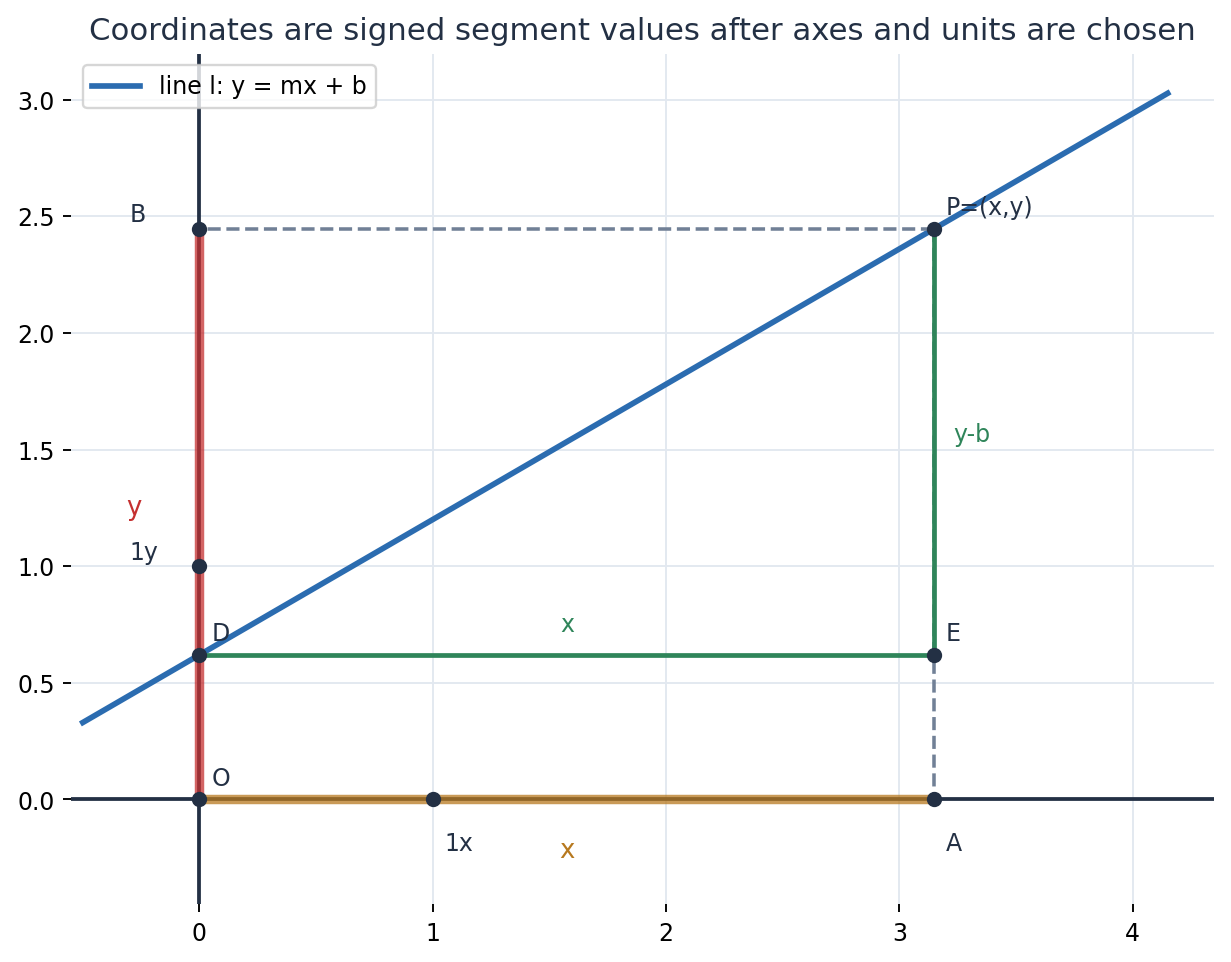

{'line_parameters': {'m': 0.58, 'b': 0.62},
 'point': {'x': 3.15, 'y': 2.4469999999999996},
 'line_residual': 0.0,
 'symbolic_line_condition': '-b - m*x + y',
 'distance_formula_residual': 0.0,
 'distance_squared': 9.649999999999999}

In [6]:
m, intercept, x_value = 0.58, 0.62, 3.15
y_value = m*x_value + intercept
P=np.array([x_value,y_value]); O=np.array([0.,0.]); A_foot=np.array([x_value,0.]); B_foot=np.array([0.,y_value]); D0=np.array([0.,intercept]); E0=np.array([x_value,intercept])
fig,ax=plt.subplots(figsize=(9.5,6.5)); ax.set_aspect('equal'); ax.grid(True,color='#e2e8f0')
for spine in ax.spines.values(): spine.set_visible(False)
ax.axhline(0,color=PALETTE['ink'],lw=1.6); ax.axvline(0,color=PALETTE['ink'],lw=1.6)
xs=np.linspace(-.5,4.15,100); ax.plot(xs,m*xs+intercept,color=PALETTE['blue'],lw=2.4,label='line l: y = mx + b')
ax.plot([P[0],A_foot[0]],[P[1],A_foot[1]],color=PALETTE['gray'],ls='--',lw=1.5); ax.plot([P[0],B_foot[0]],[P[1],B_foot[1]],color=PALETTE['gray'],ls='--',lw=1.5)
ax.plot([D0[0],E0[0],P[0]],[D0[1],E0[1],P[1]],color=PALETTE['green'],lw=2); ax.plot([O[0],A_foot[0]],[O[1],A_foot[1]],color=PALETTE['gold'],lw=4,alpha=.75); ax.plot([O[0],B_foot[0]],[O[1],B_foot[1]],color=PALETTE['red'],lw=4,alpha=.75)
for label,p,off in [('O',O,(.05,.06)),('A',A_foot,(.05,-.22)),('B',B_foot,(-.30,.03)),('D',D0,(.05,.06)),('E',E0,(.05,.06)),('P=(x,y)',P,(.05,.06)),('1x',np.array([1,0]),(.05,-.22)),('1y',np.array([0,1]),(-.30,.03))]:
    ax.scatter([p[0]],[p[1]],color=PALETTE['ink'],s=30,zorder=5); ax.text(p[0]+off[0],p[1]+off[1],label,fontsize=10,color=PALETTE['ink'])
ax.text(x_value/2,-.25,'x',ha='center',color=PALETTE['gold'],fontsize=11); ax.text(-.28,y_value/2,'y',ha='center',color=PALETTE['red'],fontsize=11); ax.text(x_value/2,intercept+.1,'x',ha='center',color=PALETTE['green'],fontsize=10); ax.text(x_value+.08,(intercept+y_value)/2,'y-b',color=PALETTE['green'],fontsize=10)
ax.set_xlim(-.55,4.35); ax.set_ylim(-.45,y_value+.75); ax.legend(loc='upper left'); ax.set_title('Coordinates are signed segment values after axes and units are chosen',fontsize=13,color=PALETTE['ink'])
coord_path=save_matplotlib(fig, UNIT, 'figures', 'coordinates-from-segment-arithmetic.png', root=ARTIFACT_ROOT, dpi=170); plt.close(fig)
x,y,mm,bb=sp.symbols('x y m b'); line_identity=sp.simplify((y-bb)-mm*x)
P1=np.array([1.2,1.0]); P2=np.array([3.8,2.7]); dx,dy=P2-P1; dist=float(np.linalg.norm(P2-P1)); dist_res=abs(dist**2-(dx**2+dy**2))
checks={'line_parameters':{'m':m,'b':intercept},'point':{'x':x_value,'y':y_value},'line_residual':abs(float(y_value-(m*x_value+intercept))),'symbolic_line_condition':str(line_identity),'distance_formula_residual':float(dist_res),'distance_squared':float(dist**2)}
CHECKS['coordinates']=checks; RESIDUALS += [checks['line_residual'], checks['distance_formula_residual']]
assert checks['line_residual'] < 1e-12 and checks['distance_formula_residual'] < 1e-12
record(coord_path, 'coordinate recovery construction', 1200)
display_artifact(coord_path, width=860)
checks


## 5. Proof Scaffold: What The Coordinate Theorem Must Preserve

The coordinate theorem is an isomorphism statement. Assigning ordered pairs is not enough; the assignment must preserve lines, betweenness, segment congruence, and angle congruence. The graph separates those preservation checks and shows their dependence on segment arithmetic and similar triangles.

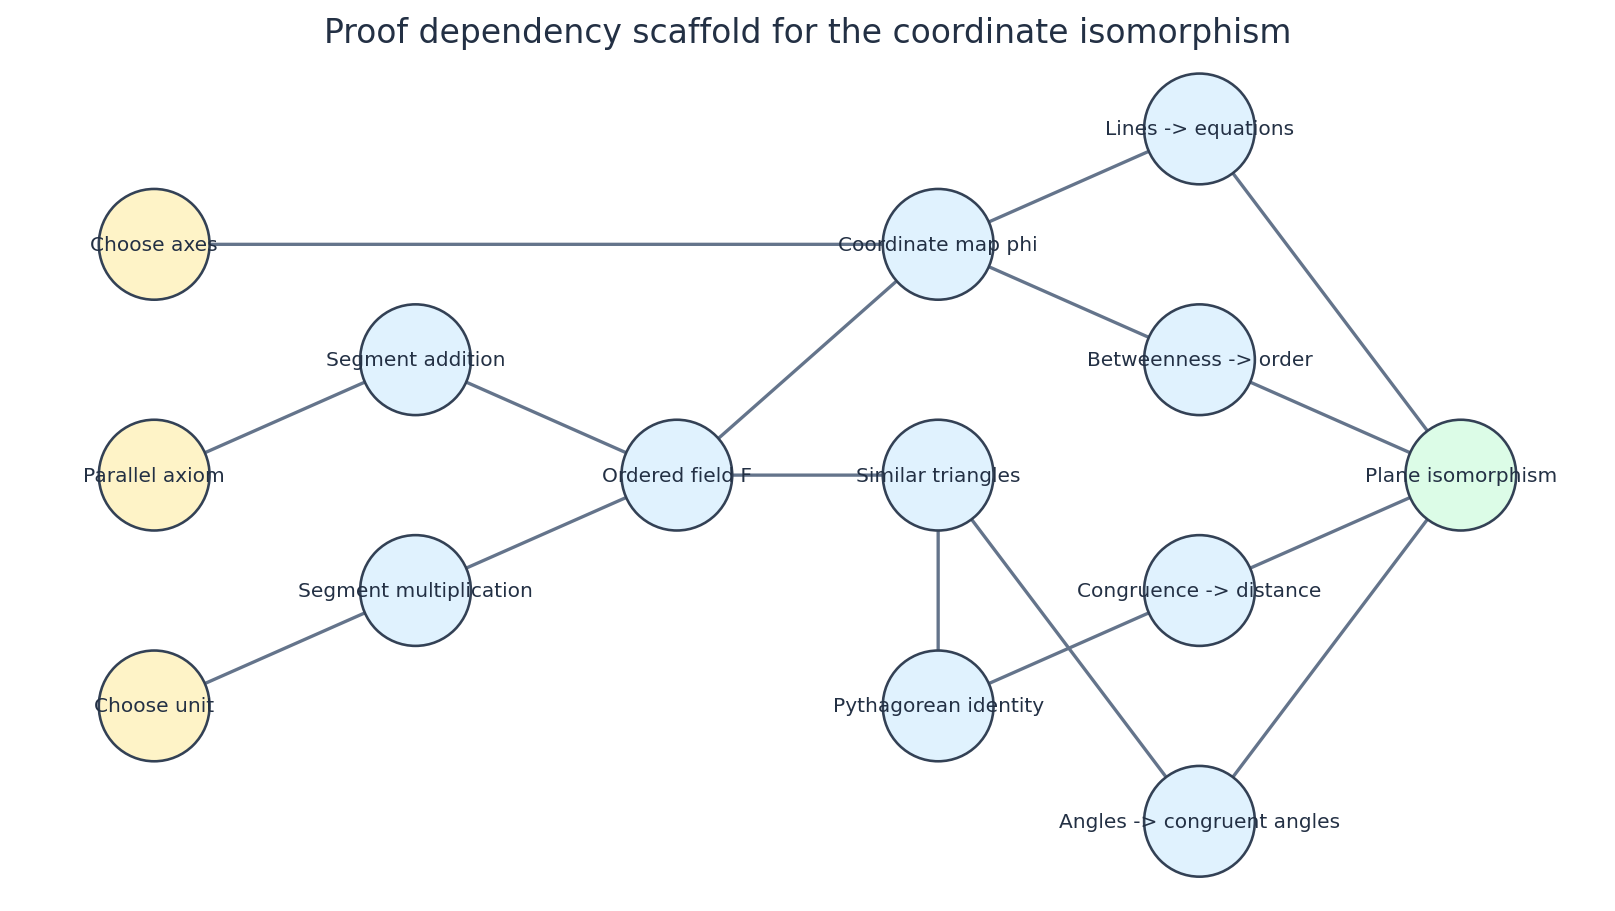

{'artifact': 'artifacts/chapter-04/figures/coordinate-isomorphism-proof-route.png',
 'node_count': 14,
 'edge_count': 16,
 'is_acyclic': True,
 'preservation_targets': ['Lines -> equations',
  'Betweenness -> order',
  'Congruence -> distance',
  'Angles -> congruent angles'],
 'all_targets_reach_isomorphism': True,
 'field_reaches_line_and_order': True}

In [7]:
proof_edges=[('Parallel axiom','Segment addition'),('Choose unit','Segment multiplication'),('Segment addition','Ordered field F'),('Segment multiplication','Ordered field F'),('Ordered field F','Similar triangles'),('Similar triangles','Pythagorean identity'),('Choose axes','Coordinate map phi'),('Ordered field F','Coordinate map phi'),('Coordinate map phi','Lines -> equations'),('Coordinate map phi','Betweenness -> order'),('Pythagorean identity','Congruence -> distance'),('Similar triangles','Angles -> congruent angles'),('Lines -> equations','Plane isomorphism'),('Betweenness -> order','Plane isomorphism'),('Congruence -> distance','Plane isomorphism'),('Angles -> congruent angles','Plane isomorphism')]
G=nx.DiGraph(proof_edges)
layers={'Parallel axiom':0,'Choose unit':0,'Choose axes':0,'Segment addition':1,'Segment multiplication':1,'Ordered field F':2,'Similar triangles':3,'Pythagorean identity':3,'Coordinate map phi':3,'Lines -> equations':4,'Betweenness -> order':4,'Congruence -> distance':4,'Angles -> congruent angles':4,'Plane isomorphism':5}
for node,layer in layers.items(): G.nodes[node]['layer']=layer
pos=nx.multipartite_layout(G, subset_key='layer', align='vertical', scale=2.2)
fig,ax=plt.subplots(figsize=(12,6.4)); ax.set_axis_off()
colors=['#fef3c7' if n in {'Parallel axiom','Choose unit','Choose axes'} else '#dcfce7' if n=='Plane isomorphism' else '#e0f2fe' for n in G.nodes]
nx.draw_networkx_edges(G,pos,ax=ax,arrows=True,arrowstyle='-|>',arrowsize=13,edge_color='#64748b',width=1.4)
nx.draw_networkx_nodes(G,pos,ax=ax,node_color=colors,edgecolors='#334155',node_size=2200,linewidths=1.1)
nx.draw_networkx_labels(G,pos,ax=ax,font_size=8.5,font_color=PALETTE['ink'])
ax.set_title('Proof dependency scaffold for the coordinate isomorphism',fontsize=14,color=PALETTE['ink'])
proof_path=save_matplotlib(fig, UNIT, 'figures', 'coordinate-isomorphism-proof-route.png', root=ARTIFACT_ROOT, dpi=170); plt.close(fig)
targets=['Lines -> equations','Betweenness -> order','Congruence -> distance','Angles -> congruent angles']
checks={'artifact':rel(proof_path),'node_count':G.number_of_nodes(),'edge_count':G.number_of_edges(),'is_acyclic':nx.is_directed_acyclic_graph(G),'preservation_targets':targets,'all_targets_reach_isomorphism':all(nx.has_path(G,t,'Plane isomorphism') for t in targets),'field_reaches_line_and_order':all(nx.has_path(G,'Ordered field F',t) for t in targets[:2])}
CHECKS['proof_scaffold']=checks
assert checks['is_acyclic'] and checks['all_targets_reach_isomorphism']
record(proof_path, 'coordinate theorem dependency graph', 1200)
display_artifact(proof_path, width=920)
checks


## Applied Lab: Vary The Unit And Watch The Product Machine

The lab varies the chosen unit while keeping physical input segment lengths visible. The table records numeric labels, physical product lengths, and residuals. The interactive HTML surface shows `product_length = a_length*b_length/unit_length`; move the unit slider to see why the chosen unit is part of the multiplication data.

In [8]:
lab_units=np.array([0.75,1.0,1.25,1.5]); lab_a=np.array([1.2,1.8,2.4]); lab_b=np.array([0.9,1.6,2.1])
rows=[]
for u0 in lab_units:
    for av in lab_a:
        for bv in lab_b:
            product=av*bv/u0; al=av/u0; bl=bv/u0; pl=product/u0
            rows.append({'unit_length':u0,'segment_a_length':av,'segment_b_length':bv,'a_label':al,'b_label':bl,'product_length':product,'product_label':pl,'label_product':al*bl,'addition_length':av+bv,'unit_identity_error':abs(av*u0/u0-av),'label_product_error':abs(pl-al*bl)})
lab_table=pd.DataFrame(rows)
lab_csv=artifact_path(UNIT,'tables','applied-segment-machine-samples.csv',root=ARTIFACT_ROOT); lab_table.to_csv(lab_csv,index=False); record(lab_csv,'applied lab sample table',256)
A,B=np.meshgrid(np.linspace(.8,3.0,45),np.linspace(.6,2.6,45))
frames=[go.Frame(data=[go.Surface(z=A*B/u0,x=A,y=B,colorscale='Viridis',showscale=False)],name=f'unit={u0:g}') for u0 in lab_units]
fig=go.Figure(data=[go.Surface(z=A*B/lab_units[0],x=A,y=B,colorscale='Viridis',colorbar={'title':'product length'})],frames=frames)
fig.update_layout(title='Similar-triangle product length as the chosen unit changes',scene={'xaxis_title':'segment a length','yaxis_title':'segment b length','zaxis_title':'a*b/unit','camera':{'eye':{'x':1.55,'y':-1.65,'z':1.15}}},width=900,height=640,margin={'l':0,'r':0,'t':55,'b':0},updatemenus=[{'type':'buttons','showactive':False,'buttons':[{'label':'Play unit sweep','method':'animate','args':[None,{'frame':{'duration':850,'redraw':True},'fromcurrent':True}]}]}],sliders=[{'steps':[{'label':f'unit {u:g}','method':'animate','args':[[f'unit={u:g}'],{'mode':'immediate','frame':{'duration':0,'redraw':True},'transition':{'duration':0}}]} for u in lab_units],'x':.1,'len':.8}])
lab_html=save_plotly_html(fig, UNIT, 'interactive', 'applied-segment-machine-lab.html', root=ARTIFACT_ROOT, include_plotlyjs='cdn'); record(lab_html,'interactive unit/product lab',1200)
lab_checks={'row_count':int(len(lab_table)),'unit_values':lab_units.tolist(),'max_label_product_error':float(lab_table['label_product_error'].max()),'max_unit_identity_error':float(lab_table['unit_identity_error'].max()),'product_length_min':float(lab_table['product_length'].min()),'product_length_max':float(lab_table['product_length'].max()),'table_artifact':rel(lab_csv),'interactive_artifact':rel(lab_html)}
lab_checks_path=save_json(lab_checks, UNIT, 'checks', 'applied-lab-checks.json', root=ARTIFACT_ROOT); record(lab_checks_path,'applied lab invariant checks',256)
CHECKS['applied_lab']=lab_checks; RESIDUALS += [lab_checks['max_label_product_error'], lab_checks['max_unit_identity_error']]
assert lab_checks['row_count'] == len(lab_units)*len(lab_a)*len(lab_b)
assert lab_checks['max_label_product_error'] < 1e-12 and lab_checks['max_unit_identity_error'] < 1e-12
display_artifact(lab_html, width='100%', height=660)
lab_table.head(12)


,unit_length,segment_a_length,segment_b_length,a_label,b_label,product_length,product_label,label_product,addition_length,unit_identity_error,label_product_error
0,0.75,1.2,0.9,1.6,1.200000,1.44,1.920000,1.920000,2.1,0.0,4.440892e-16
1,0.75,1.2,1.6,1.6,2.133333,2.56,3.413333,3.413333,2.8,0.0,4.440892e-16
2,0.75,1.2,2.1,1.6,2.800000,3.36,4.480000,4.480000,3.3,0.0,8.881784e-16
3,0.75,1.8,0.9,2.4,1.200000,2.16,2.880000,2.880000,2.7,0.0,4.440892e-16
4,0.75,1.8,1.6,2.4,2.133333,3.84,5.120000,5.120000,3.4,0.0,0.000000e+00
5,0.75,1.8,2.1,2.4,2.800000,5.04,6.720000,6.720000,3.9,0.0,8.881784e-16
6,0.75,2.4,0.9,3.2,1.200000,2.88,3.840000,3.840000,3.3,0.0,8.881784e-16
7,0.75,2.4,1.6,3.2,2.133333,5.12,6.826667,6.826667,4.0,0.0,8.881784e-16
8,0.75,2.4,2.1,3.2,2.800000,6.72,8.960000,8.960000,4.5,0.0,1.776357e-15
9,1.00,1.2,0.9,1.2,0.900000,1.08,1.080000,1.080000,2.1,0.0,0.000000e+00


## Final Sanity Checks

The final cell checks core identities, artifact existence, nonzero artifact sizes, proof graph structure, and applied-lab residuals. It writes `visual-checks.json`, `final-sanity.json`, and the course-compatible `notebook-sanity.json`.

In [9]:
visual_summary={'unit':UNIT,'source_span':'printed pp. 165-194 / PDF pp. 177-206, Sections 19-21','library_routing':{'matplotlib':'2D synthetic construction diagrams','plotly':'interactive unit/product parameter lab','sympy':'exact arithmetic and coordinate identities','networkx':'proof-dependency graph','pandas':'lab tables with residuals'},'artifacts':[r['path'] for r in ARTIFACTS],'checks':CHECKS,'max_numeric_residual':float(max(RESIDUALS) if RESIDUALS else 0.0)}
visual_checks_path=save_json(visual_summary, UNIT, 'checks', 'visual-checks.json', root=ARTIFACT_ROOT); record(visual_checks_path,'visual and invariant ledger',512)
artifact_status=[]
for item in ARTIFACTS:
    checked=assert_artifact(BOOK_ROOT/item['path'], min_bytes=item['min_bytes'])
    artifact_status.append({'path':item['path'],'role':item['role'],'bytes':checked.stat().st_size})
final_sanity={'unit':UNIT,'source_span':'printed pp. 165-194 / PDF pp. 177-206, Sections 19-21','artifact_count':len(artifact_status),'artifacts':artifact_status,'all_artifacts_nonzero':all(a['bytes']>0 for a in artifact_status),'addition_associative_residual':CHECKS['addition']['associative_residual'],'multiplication_slope_residual':CHECKS['multiplication']['slope_residual'],'unit_choice_label_product_residual':CHECKS['unit_choice']['max_label_product_residual'],'coordinate_line_residual':CHECKS['coordinates']['line_residual'],'coordinate_distance_formula_residual':CHECKS['coordinates']['distance_formula_residual'],'proof_graph_is_acyclic':CHECKS['proof_scaffold']['is_acyclic'],'applied_lab_rows':CHECKS['applied_lab']['row_count'],'max_numeric_residual':float(max(RESIDUALS) if RESIDUALS else 0.0)}
final_sanity_path=save_json(final_sanity, UNIT, 'checks', 'final-sanity.json', root=ARTIFACT_ROOT)
notebook_sanity_path=save_json(final_sanity, UNIT, 'checks', 'notebook-sanity.json', root=ARTIFACT_ROOT)
assert_artifact(final_sanity_path, min_bytes=512); assert_artifact(notebook_sanity_path, min_bytes=512)
assert final_sanity['all_artifacts_nonzero'] and final_sanity['artifact_count'] >= 8
assert final_sanity['max_numeric_residual'] < 1e-10 and final_sanity['proof_graph_is_acyclic']
final_sanity


{'unit': 'chapter-04',
 'source_span': 'printed pp. 165-194 / PDF pp. 177-206, Sections 19-21',
 'artifact_count': 10,
 'artifacts': [{'path': 'artifacts/chapter-04/figures/segment-arithmetic-machine.png',
   'role': 'chapter dependency route',
   'bytes': 84966},
  {'path': 'artifacts/chapter-04/figures/segment-addition-order.png',
   'role': 'segment addition construction',
   'bytes': 38719},
  {'path': 'artifacts/chapter-04/figures/similar-triangle-product-machine.png',
   'role': 'similar-triangle multiplication construction',
   'bytes': 45684},
  {'path': 'artifacts/chapter-04/figures/unit-segment-scale-choice.png',
   'role': 'unit segment calibration comparison',
   'bytes': 43901},
  {'path': 'artifacts/chapter-04/figures/coordinates-from-segment-arithmetic.png',
   'role': 'coordinate recovery construction',
   'bytes': 67499},
  {'path': 'artifacts/chapter-04/figures/coordinate-isomorphism-proof-route.png',
   'role': 'coordinate theorem dependency graph',
   'bytes': 17112

## Takeaways

- Segment addition is a betweenness construction: place representatives end to end and read the total endpoint.
- Segment multiplication needs a unit segment; the unit turns an angle/slope comparison in two right triangles into a product segment.
- Similar triangles become field equations only after segment arithmetic supplies addition, multiplication, and ratios.
- The coordinate theorem closes the logical circle: Hilbert-plane geometry plus the parallel axiom builds a field `F`, and points can then be represented by ordered pairs in `F^2` while preserving lines, betweenness, congruence, and angles.
- Changing the chosen unit leaves physical addition alone but changes multiplication calibration, so the identity element is construction data.
